In [1]:
# TASK 1: Fetch Data from API

import json
import requests
import os
import datetime
import time

# Category keywords
categories = {
    "Technology": [
        "AI", "software", "tech", "code", "computer",
        "data", "cloud", "API", "GPU", "LLM"
    ],
    "Worldnews": [
        "war", "government", "country", "president",
        "election", "climate", "attack", "global"
    ],
    "Sports": [
        "NFL", "NBA", "FIFA", "sport", "game",
        "team", "player", "league", "championship"
    ],
    "Science": [
        "research", "study", "space", "physics",
        "biology", "discovery", "NASA", "genome"
    ],
    "Entertainment": [
        "movie", "film", "music", "Netflix", "game",
        "book", "show", "award", "streaming"
    ]
}

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Fetch top story IDs
try:
    response = requests.get(
        "https://hacker-news.firebaseio.com/v0/topstories.json"
    )
    response.raise_for_status()
    top_stories = response.json()

except requests.RequestException:
    print("Failed to fetch top stories!")
    exit()

# Store all collected stories
all_stories_list = []

# Required fields in each Hacker News story
story_require = [
    "id",
    "title",
    "score",
    "descendants",
    "by"
]

# Keep track of stories already collected
collected_ids = set()

# Process each category
for category, keywords in categories.items():

    story_count = 0

    # Check top stories until this category reaches 25
    for story_id in top_stories:

        if story_count >= 25:
            break

        # Don't collect the same story in another category
        if story_id in collected_ids:
            continue

        # Fetch individual story
        try:
            story_response = requests.get(
                f"https://hacker-news.firebaseio.com/v0/item/{story_id}.json"
            )
            story_response.raise_for_status()
            story = story_response.json()

        except requests.RequestException:
            print(f"Failed to fetch story {story_id}!")
            continue

        # Skip empty story data
        if not story:
            continue

        # Check required fields
        if not all(field in story for field in story_require):
            continue

        # Convert title to lowercase for keyword matching
        title = story["title"].lower()

        # Check whether any keyword matches
        match_found = False

        for keyword in keywords:
            if keyword.lower() in title:
                match_found = True
                break

        # Create record if keyword matched
        if match_found:

            story_record = {
                "post_id": story["id"],
                "title": story["title"],
                "category": category,
                "score": story["score"],
                "num_comments": story["descendants"],
                "author": story["by"],
                "collected_at": datetime.datetime.now().isoformat()
            }

            all_stories_list.append(story_record)

            # Mark story as collected
            collected_ids.add(story_id)

            # Increase category count
            story_count += 1

    # Wait 2 seconds between categories
    time.sleep(2)


# Create date-based output filename
output_filename = (
    f"data/trends_{datetime.datetime.now().strftime('%Y%m%d')}.json"
)

# Save collected stories
with open(output_filename, "w") as f:
    json.dump(all_stories_list, f, indent=2)

# Final result
print(
    f"Collected {len(all_stories_list)} stories. "
    f"Saved to {output_filename}"
)

Collected 96 stories. Saved to data/trends_20260926.json


Task 1 – Data Collection:
*   Used the Hacker News API to fetch top stories.
*   Categorized stories into Technology, Worldnews, Sports, Science, and Entertainment.
*   Collected matching stories and saved the raw data as JSON.







In [3]:
# TASK 2: Clean the Data and save asCSV

import pandas as pd
import numpy as np


# TASK 2: LOAD, CLEAN AND ANALYZE DATA

# 1. Load the JSON file

file_path = "/content/data/trends_20260926.json"
df = pd.read_json(file_path)
print(f"Loaded {len(df)} stories from {file_path}")

# 2. Remove duplicate posts

df = df.drop_duplicates(subset=['post_id'])
print(f"After removing duplicates: {len(df)}")

# 3. Remove rows with missing values

df = df.dropna(subset=['post_id', 'title', 'score'])
print(f"After removing nulls: {len(df)}")

# 4. Strip whitespace from title

df['title'] = df['title'].str.strip()

# 5. Convert numeric columns to integers

df[['score', 'num_comments']] = (df[['score', 'num_comments']].astype(int))

# 6. Remove posts with score less than 5

df = df[df['score'] >= 5]

print(f"After removing low scores: {len(df)}")

# 7. Count stories per category

category_counts = df['category'].value_counts()
print("\nStories per category:")
for category, count in category_counts.items():
    print(f"  {category:<15} {count}")

# 8. Minimum, maximum and average score

min_score = df['score'].min()
max_score = df['score'].max()
avg_score = df['score'].mean()

print("\nScore statistics:")
print(f"Minimum score: {min_score}")
print(f"Maximum score: {max_score}")
print(f"Average score: {avg_score:.2f}")

# 9. Number of unique posts

unique_posts = df['post_id'].nunique()
print(f"Unique posts: {unique_posts}")

# 10. Check missing values

missing_values = df.isna().sum()
print("\nMissing values:")
print(missing_values)

# 11. Find highest-scoring post

highest_row = df.loc[df['score'].idxmax()]
print("\nHighest-scoring post:")
print(highest_row)

# 12. Find post with lowest comments

lowest_comment_row = df.loc[df['num_comments'].idxmin()]
print("\nPost with lowest comments:")
print(lowest_comment_row)

# 13. Create engagement column

df['engagement'] = (df['score'] + df['num_comments'])

# 14. Create engagement rate

df['engagement_rate'] = np.where(df['score'] > 0,(df['score'] + df['num_comments']) / df['score'],0)

# 15. Create score category

df['score_category'] = np.select([df['score'] >= 100,df['score'] >= 10],['High','Medium'],default='Low')

# 16. Top 5 posts by number of comments

high_comments_df = df.sort_values(by='num_comments',ascending=False)
print("\nTop 5 posts by comments:")
print(high_comments_df[['post_id', 'title', 'score', 'num_comments']].head(5))

# 17. Average comments for score >= 10

avg_comments = (df[df['score'] >= 10]['num_comments'].mean())
print(f"\nAverage comments for score >= 10: "f"{avg_comments:.2f}")

# 18. Count posts with score > 100

high_score_count = (df['score'] > 100).sum()
print(f"Posts with score > 100: {high_score_count}")

# 19. Percentage of posts with score >= 10

percentage_high_score = ((df['score'] >= 10).sum()/ len(df)) * 100
print(f"Percentage with score >= 10: "f"{percentage_high_score:.2f}%")

# 20. Find Python-related posts

python_posts = df[df['title'].str.contains('python',case=False,na=False)]
print(f"\nPython-related posts: "f"{len(python_posts)}")

# 21. Save cleaned dataset

output_file = "data/trends_clean.csv"
df.to_csv(output_file, index=False)
print(f"\nSaved {len(df)} rows to {output_file}")

Loaded 96 stories from /content/data/trends_20260926.json
After removing duplicates: 96
After removing nulls: 96
After removing low scores: 88

Stories per category:
  Entertainment   25
  Technology      23
  Worldnews       22
  Sports          10
  Science         8

Score statistics:
Minimum score: 5
Maximum score: 952
Average score: 127.67
Unique posts: 88

Missing values:
post_id         0
title           0
category        0
score           0
num_comments    0
author          0
collected_at    0
dtype: int64

Highest-scoring post:
post_id                                                  49841563
title           Dutch governments builds alternative for Micro...
category                                                Worldnews
score                                                         952
num_comments                                                  549
author                                                    fjfaase
collected_at                           2026-09-26 07:10:23.47

Task 2 – Data Cleaning:
*   Loaded the JSON data using Pandas and removed duplicates and missing values.
*   Converted numeric columns and removed stories with scores below 5.
*   Performed basic statistics and saved the cleaned data as trends_clean.csv.

In [4]:
# TASK 3: Analysis with Pandas and NumPy

import pandas as pd
import numpy as np

# 1 — Load and Explore

df = pd.read_csv("data/trends_clean.csv")

print("Loaded data:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nAverage score:", df['score'].mean())
print("Average comments:", df['num_comments'].mean())

# 2 — Basic Analysis with NumPy

mean_score = np.mean(df['score'])
median_score = np.median(df['score'])
std_score = np.std(df['score'])

print("\n--- NumPy Stats ---")
print("Mean score:", mean_score)
print("Median score:", median_score)
print("Std deviation:", std_score)

max_score = np.max(df['score'])
min_score = np.min(df['score'])

print("Max score:", max_score)
print("Min score:", min_score)


# Category with the most stories
category_counts = df['category'].value_counts()

most_category = category_counts.idxmax()
most_category_count = category_counts.max()

print(
    f"Most stories in: {most_category} "
    f"({most_category_count} stories)"
)


# Story with the most comments
index = df['num_comments'].idxmax()
high_comments = df.loc[index]

print(
    f'Most commented story: "{high_comments["title"]}" '
    f'— {high_comments["num_comments"]} comments'
)

# 3 — Add New Columns

# Engagement = comments per upvote
df['engagement'] = df['num_comments'] / (df['score'] + 1)

# Popular if score is greater than average score
df['is_popular'] = df['score'] > mean_score

# 4 — Save the Result

output_file = "data/trends_analysed.csv"
df.to_csv(output_file, index=False)
print(f"\nAnalysis completed and saved to {output_file}")


Loaded data: (88, 10)

First 5 rows:
    post_id                                              title    category  \
0  49849985  Revealing the details of how OpenAI agents hac...  Technology   
1  49853175  A single function Jev-like wrapper for LLMs, i...  Technology   
2  49836579  How I changed teaching after AI managed to do ...  Technology   
3  49823490                A new world airport and its baggage  Technology   
4  49852065  One Piece of Flock Camera Data Put This Innoce...  Technology   

   score  num_comments          author                collected_at  \
0    403           244  specked-citrus  2026-09-26 07:10:18.768949   
1     39             2        allanrbo  2026-09-26 07:10:18.787729   
2     41             8        azhenley  2026-09-26 07:10:18.924352   
3      8             1         firloop  2026-09-26 07:10:18.939074   
4    153            56      HotGarbage  2026-09-26 07:10:19.001167   

   engagement  engagement_rate score_category  
0         647         1.6

Task 3 – Data Analysis:
*   Calculated score statistics using NumPy and Pandas.
*   Identified the highest/lowest scores, most common category, and most-commented story.
*   Added engagement and is_popular columns and saved trends_analysed.csv.

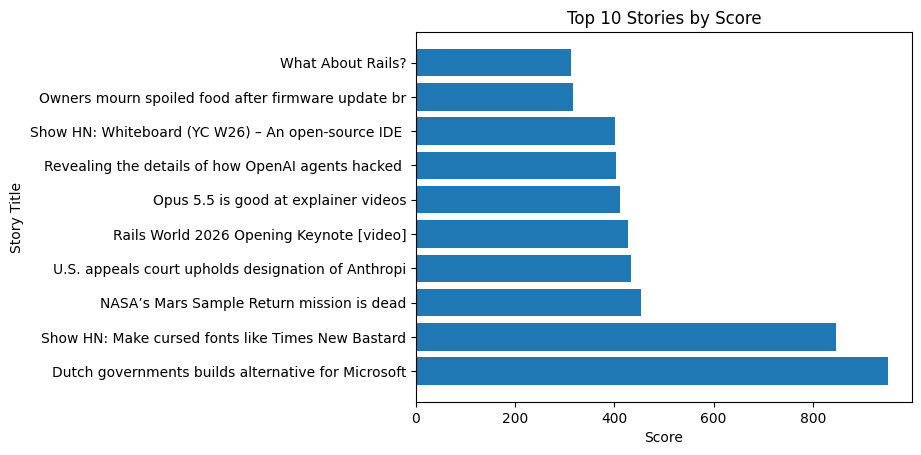

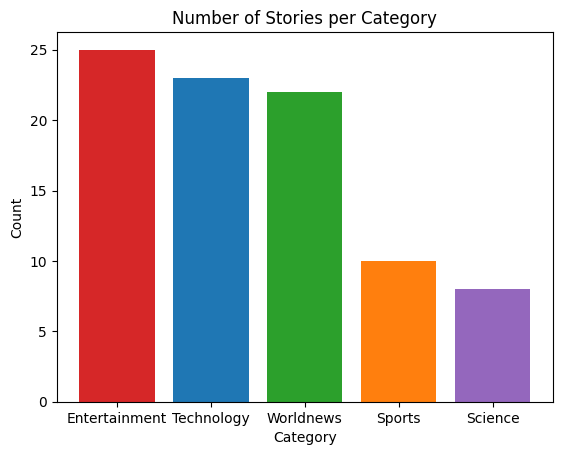

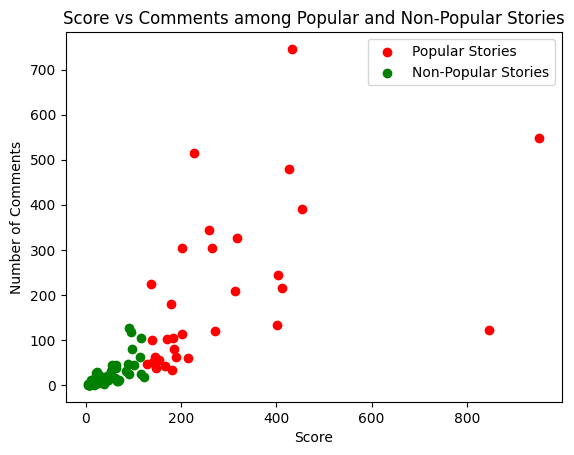

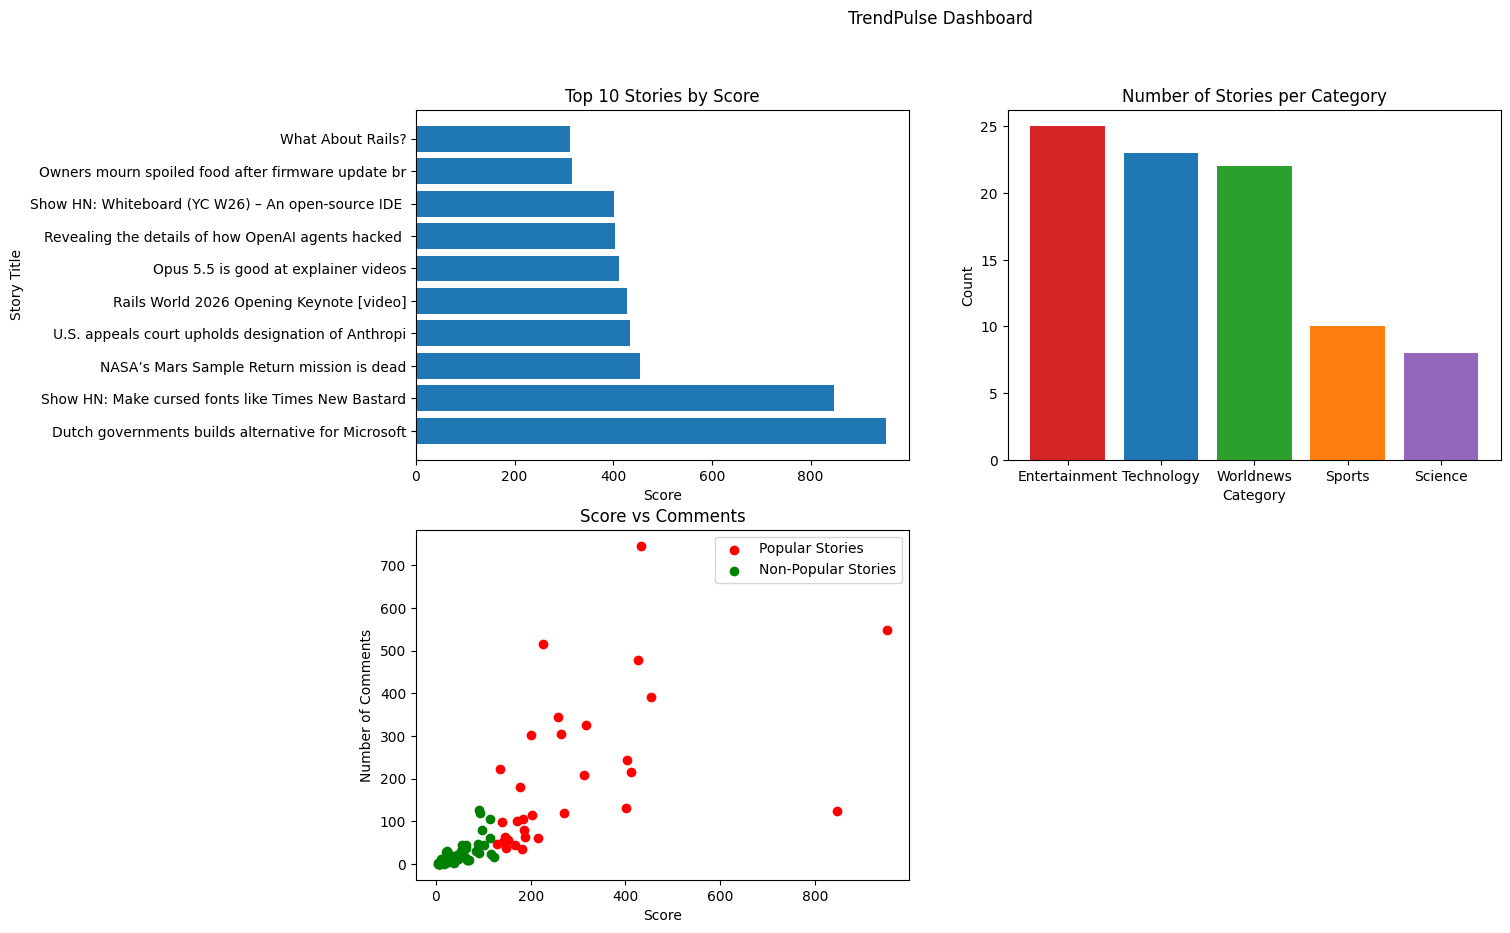

In [6]:
# TASK 4: Data Visualizations

import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. SETUP

# Load the analysed data
df = pd.read_csv("data/trends_analysed.csv")

# Create outputs folder if it doesn't exist
os.makedirs("outputs", exist_ok=True)

# 2. CHART 1 — TOP 10 STORIES BY SCORE

# Sort by score and select top 10
df_top = df.sort_values(by='score', ascending=False).head(10)

# Shorten long titles
def shorten_title(title):
    if len(title) > 50:
        return title[:50]
    return title

df_top['short_title'] = df_top['title'].apply(shorten_title)

# Create horizontal bar chart
plt.barh(df_top['short_title'], df_top['score'])

plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")

# Save before show
plt.savefig("outputs/chart1_top_stories.png")
plt.show()

# 3. CHART 2 — STORIES PER CATEGORY

# Count stories in each category
category_counts = df['category'].value_counts()

# Different color for each bar
bar_colors = [
    'tab:red',
    'tab:blue',
    'tab:green',
    'tab:orange',
    'tab:purple'
]

# Create bar chart
plt.bar(category_counts.index,category_counts.values,color=bar_colors)

plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Number of Stories per Category")

# Save before show
plt.savefig("outputs/chart2_categories.png")
plt.show()

# 4. CHART 3 — SCORE VS COMMENTS

# Separate popular and non-popular stories
popular = df[df['is_popular'] == True]
non_popular = df[df['is_popular'] == False]

# Popular stories
plt.scatter(
    popular['score'],
    popular['num_comments'],
    c='red',
    label='Popular Stories'
)

# Non-popular stories
plt.scatter(
    non_popular['score'],
    non_popular['num_comments'],
    c='green',
    label='Non-Popular Stories'
)

plt.title("Score vs Comments among Popular and Non-Popular Stories")
plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.legend()

# Save before show
plt.savefig("outputs/chart3_scatter.png")
plt.show()

# 5. BONUS — COMBINED DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — Top 10 Stories
axes[0,0].barh(
    df_top['short_title'],
    df_top['score']
)

axes[0,0].set_xlabel("Score")
axes[0,0].set_ylabel("Story Title")
axes[0,0].set_title("Top 10 Stories by Score")


# Chart 2 — Categories
axes[0,1].bar(
    category_counts.index,
    category_counts.values,
    color=bar_colors
)

axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Count")
axes[0,1].set_title("Number of Stories per Category")


# Chart 3 — Score vs Comments
axes[1,0].scatter(
    popular['score'],
    popular['num_comments'],
    c='red',
    label='Popular Stories'
)

axes[1,0].scatter(
    non_popular['score'],
    non_popular['num_comments'],
    c='green',
    label='Non-Popular Stories'
)

axes[1,0].set_title("Score vs Comments")
axes[1,0].set_xlabel("Score")
axes[1,0].set_ylabel("Number of Comments")
axes[1,0].legend()

# Hide unused subplots

axes[1, 1].axis('off')


# Overall dashboard title
fig.suptitle("TrendPulse Dashboard")

# Save dashboard
plt.savefig("outputs/dashboard.png")
plt.show()

Task 4 – Visualization:
*   Created three Matplotlib charts: Top 10 Stories, Stories per Category, and Score vs Comments.
*   Distinguished popular and non-popular stories using different colors.
*   Combined all three charts into the TrendPulse Dashboard and saved the PNG files.